The goal of this script is to take in .csv TTL data from our 2p imaging setup (two cameras and calcium imaging) and align the camera data with the scope (3 videos side by side)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import nibabel as nib
import xml.etree.ElementTree as ET
from IPython.display import Video
import cv2
import imageio
import os
import math
from scipy.spatial import cKDTree
from tqdm import tqdm

In [2]:
def read_csv(filename):
    data = pd.read_csv(filename)
    data.columns = data.columns.str.strip()
    # Determine which column is the scope by comparing the average voltage
    column_means = np.floor(data.mean())
    for idx, column_mean in enumerate(column_means):
        if column_mean == 0:
            scope_idx = idx
        elif 0 < column_mean < 5:
            side_camera_idx = idx

    # front_camera_idx = np.argmax(column_means)
        
    # Rename columns for easier access
    # if len(data.columns) == 4:
    #     data = data.rename(columns={f'{data.columns[1]}': 'Scope', f'{data.columns[2]}': 'Side Camera', f'{data.columns[3]}': 'Front Camera'})
    if len(data.columns) == 3:
        data = data.rename(columns={f'{data.columns[scope_idx]}': 'Scope', f'{data.columns[side_camera_idx]}': 'Side Camera'})
    return data

def get_TTL_frame_rate(data):
    '''Get the frame rate of the TTL data in Hz'''

    return get_frame_rate(data['Time(ms)'])

def get_TTL_frame_period(data):
    '''Get the frame period of the TTL data in ms'''

    return get_frame_period(data['Time(ms)'])

def get_frame_period(timestamps):
    '''Get the frame period ms'''

    frame_period = np.mean(timestamps.diff().dropna())
    return float(frame_period)

def get_frame_rate(timestamps):
    '''Get the frame rate Hz'''

    frame_rate = 1 / np.mean(timestamps.diff().dropna())
    return float(frame_rate * 1000) # Convert to Hz from mHz

def get_TTL_data_specs(data, output=False):
    '''Get the specifications of the data'''

    TTL_frame_rate = get_TTL_frame_rate(data)
    TTL_frame_period = get_TTL_frame_period(data)

    if output:
        print(f'TTL recording rate: {TTL_frame_rate:.2f} Hz')
        print(f'TTL recording period: {TTL_frame_period:.2f} ms')
    
    return TTL_frame_rate, TTL_frame_period

def extract_2p_relative_timestamps(data, threshold=5):
    scope_on_signals = data[data['Scope'] > threshold]
    first_signal = scope_on_signals['Time(ms)'].iloc[0]

    timestamps = scope_on_signals[scope_on_signals['Time(ms)'].diff() > 2 * get_TTL_frame_period(data)]['Time(ms)']
    timestamps = np.concatenate([[first_signal], timestamps.to_numpy()])

    # Leave only every 31st timestamp
    timestamps = timestamps[::31]
    
    return timestamps

def extract_camera_relative_timestamps(data, threshold=3):
    camera_on_signals = data[data['Side Camera'] > threshold]
    first_signal = camera_on_signals['Time(ms)'].iloc[0]

    # Get the first in clusters (voltage is ~3.65 V for whole camera exposure)
    timestamps = camera_on_signals[camera_on_signals['Time(ms)'].diff() > 2 * get_TTL_frame_period(data)]['Time(ms)']
    timestamps = np.concatenate([[first_signal], timestamps.to_numpy()])

    return timestamps

def run_alaysis(data, output=False, plot=False):
    scope_timestamps = extract_2p_relative_timestamps(data)
    camera_timestamps = extract_camera_relative_timestamps(data)

    scope_frame_period = get_frame_period(pd.Series(scope_timestamps))
    scope_frame_rate = get_frame_rate(pd.Series(scope_timestamps))

    camera_frame_period = get_frame_period(pd.Series(camera_timestamps))
    camera_frame_rate = get_frame_rate(pd.Series(camera_timestamps))

    TTL_frame_rate, TTL_frame_period = get_TTL_data_specs(data)


    if output:
        print(f'Scope frame rate: {scope_frame_rate:.2f} Hz')
        print(f'Scope frame period: {scope_frame_period:.2f} ms')
        print(f'Camera frame rate: {camera_frame_rate:.2f} Hz')
        print(f'Camera frame period: {camera_frame_period:.2f} ms')
        print(f'TTL recording rate: {TTL_frame_rate:.2f} Hz')
        print(f'TTL recording period: {TTL_frame_period:.2f} ms')

    if plot:
        plt.plot(data['Time(ms)'], data['Side Camera'], label='Camera TTL Trace')
        plt.plot(data['Time(ms)'], data['Scope'], label='2P TTL Trace')
        plt.vlines(camera_timestamps, 0, 6, colors='tab:blue', linestyles='solid', alpha=0.25)
        plt.vlines(scope_timestamps, 0, 6, colors='tab:orange', linestyles='solid', alpha=0.25)
        plt.scatter(camera_timestamps, 6 * np.ones(len(camera_timestamps)), color='tab:blue', alpha=0.8, label='Camera Timestamps')
        plt.scatter(scope_timestamps, 6 * np.ones(len(scope_timestamps)), color='tab:orange', alpha=0.8, label='2P Timestamps')
        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
        plt.xlabel('Time (ms)')
        plt.ylabel('Voltage (V)')
        plt.title('Camera and 2P TTL Traces with Triggers')
        plt.xlim(-5, 200)
        plt.show()


    return scope_timestamps, camera_timestamps

def load_nifti(video_path):
    return nib.load(video_path)

def align_videos(scope_timestamps, side_camera_timestamps, scope_video=None, side_camera_video=None):
    '''Takes in the frame capture timestamps and aligns the three videos (scope, front camera, side camera)
    '''

    if scope_video is not None:
        # Load the scope video (.nii)
        scope_array = scope_video.get_fdata()
        max_projection = scope_array.max(axis=2)
        # print('Displaying first 10 max projected volumes')
        # for i, projection in enumerate(max_projection.swapaxes(0,2)):
        #     if i < 10:
        #         plt.imshow(projection)
        #         plt.show()
    else:
        # Make scope video blank
        scope_array = np.zeros((256, 125, 31, len(scope_timestamps)))
        print('No scope video provided, creating blank video')

    if side_camera_video is not None:
        # Load the side camera video (.mp4)
        pass
    else:
        # Make side camera video blank
        side_camera_array = np.zeros((512, 512, 10, len(side_camera_timestamps)))
        print('No side camera video provided, creating blank video')

def read_xml(xml_file_path):
    tree = ET.parse(xml_file_path)
    root = tree.getroot()
    frames = [x.find("Frame") for x in root]
    sequences = [x.find("Sequence") for x in root]
    # my_text = [item.text for item in tree.iter()]
    print(f'Frames: {len(frames)}')
    print(f'Sequences: {len(sequences)}')

In [ ]:
data = read_csv('/home/ptarabishi/projects/maui_codebook/data/TSeries_20251217-101_Cycle00001_VoltageRecording_001.csv')

   Time(ms)     Scope  Side Camera
0      0.00 -0.000916     1.387939
1      0.01 -0.000916     3.094177
2      0.02 -0.000916     3.228455
3      0.03 -0.000916     3.266907
4      0.04 -0.000916     3.279419
0.03575760861893003
3.425070777531072
Scope frame rate: 3.70 Hz
Scope frame period: 270.35 ms
Camera frame rate: 130.72 Hz
Camera frame period: 7.65 ms
TTL recording rate: 100000.00 Hz
TTL recording period: 0.01 ms


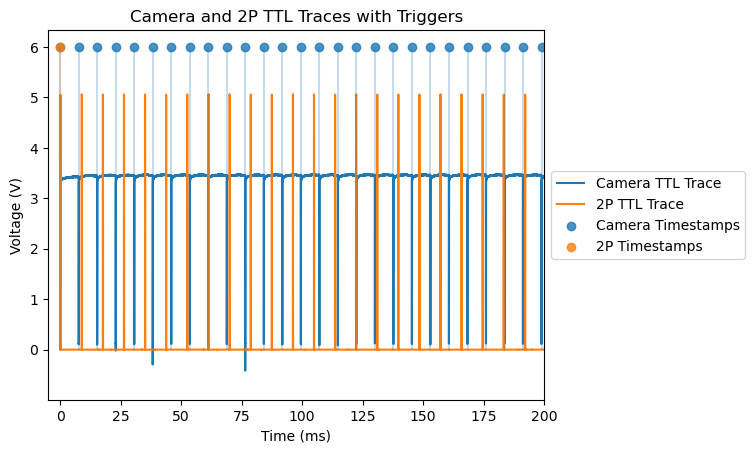

Number of scope timestamps: 2221
Number of camera timestamps: 78363


In [ ]:
print(data.head())
print(np.mean(data['Scope']))
print(np.mean(data['Side Camera']))

scope_timestamps, camera_timestamps = run_alaysis(data, output=True, plot=True)
print(f'Number of scope timestamps: {len(scope_timestamps)}')
print(f'Number of camera timestamps: {len(camera_timestamps)}')

In [ ]:
# read_xml('TSeries-05152025-1300-003.xml')

Frames: 2222
Sequences: 2222


In [ ]:
scope_video = load_nifti('/home/ptarabishi/projects/maui_codebook/data/TSeries_20251217-101_channel_2.nii')
scope_video.get_fdata().shape

(256, 125, 31, 2220)

In [9]:
current_path = os.getcwd()
print(f'Current path: {current_path}')

Current path: c:\Users\carte\OneDrive\Documents\Ahmed Lab\Flyball Rig\Atlas-Maui Synchronization


In [ ]:
def create_video_aligned_to_camera(
    scope_nii_path,
    behavior_avi_path,
    scope_timestamps,
    camera_timestamps,
    output_path="aligned_output.avi",
    scope_scale=1.5,
    max_frames=None
):
    def apply_colormap_viridis(gray_image):
        normed = (gray_image - gray_image.min()) / (gray_image.ptp() + 1e-8)
        viridis = plt.get_cmap('viridis')
        colored = viridis(normed)
        return (colored[:, :, :3] * 255).astype(np.uint8)


    scope_img = nib.load(scope_nii_path)
    scope_timestamps = np.array(scope_timestamps)
    camera_timestamps = np.array(camera_timestamps)

    cap = cv2.VideoCapture(behavior_avi_path)
    cam_fps = cap.get(cv2.CAP_PROP_FPS)
    cam_n_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cam_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    cam_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    print(f"Camera video: {cam_n_frames} frames at {cam_fps:.2f} FPS")

    if max_frames is None:
        num_output_frames = cam_n_frames
    else:
        num_output_frames = min(max_frames, cam_n_frames)

    sample_scope = np.array(scope_img.dataobj[..., 0])
    proj = np.max(sample_scope, axis=2)
    scope_h, scope_w = proj.shape
    scope_scaled_h = int(scope_h * scope_scale)
    scope_scaled_w = int(scope_w * scope_scale)

    output_height = max(scope_scaled_h, cam_height)
    output_width = cam_width + scope_scaled_w
    padded_width = int(math.ceil(output_width / 16) * 16)

    scope_tree = cKDTree(scope_timestamps.reshape(-1, 1))

    fourcc = cv2.VideoWriter_fourcc(*'XVID')
    writer = cv2.VideoWriter(output_path, fourcc, cam_fps, (padded_width, output_height))

    print(f"Generating video at {cam_fps:.2f} FPS...")

    for frame_idx in tqdm(range(num_output_frames)):
        if frame_idx >= len(camera_timestamps):
            break
        t = camera_timestamps[frame_idx]

        # Scope frame
        _, s_idx = scope_tree.query([[t]])
        s_idx = int(s_idx[0])
        scope_frame = np.array(scope_img.dataobj[..., s_idx])
        proj = np.max(scope_frame, axis=2)
        vmin, vmax = np.percentile(proj, [1, 99])
        proj = np.clip(proj, vmin, vmax)
        proj_norm = ((proj - vmin) / (vmax - vmin + 1e-8) * 255).astype(np.uint8)
        colored = apply_colormap_viridis(proj_norm)
        scope_resized = cv2.resize(colored, (scope_scaled_w, scope_scaled_h))
        scope_padded = np.zeros((output_height, scope_scaled_w, 3), dtype=np.uint8)
        scope_padded[:scope_resized.shape[0], :scope_resized.shape[1]] = scope_resized

        # Camera frame
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, cam_frame = cap.read()
        if not ret:
            print(f"Failed to read frame {frame_idx}")
            break

        cam_padded = np.zeros((output_height, cam_width, 3), dtype=np.uint8)
        cam_padded[:cam_frame.shape[0], :cam_frame.shape[1]] = cam_frame

        # Combine and write frame
        combined = np.hstack((cam_padded, scope_padded))
        final_frame = np.zeros((output_height, padded_width, 3), dtype=np.uint8)
        final_frame[:, :combined.shape[1]] = combined

        writer.write(final_frame)

    cap.release()
    writer.release()
    print(f"Output video saved to {output_path} at {cam_fps:.2f} FPS")


In [26]:
print(f'Number of scope timestamps: {len(scope_timestamps)}')
print(f'Number of camera timestamps: {len(camera_timestamps)}')

Number of scope timestamps: 2221
Number of camera timestamps: 78363


In [ ]:
create_video_aligned_to_camera(
    scope_nii_path="/home/ptarabishi/projects/maui_codebook/data/TSeries_20251217-101_channel_2.nii",
    behavior_avi_path="250515-f3.avi",
    scope_timestamps=scope_timestamps,
    camera_timestamps=camera_timestamps,
    output_path="aligned_output.avi",
    scope_scale=2,
    max_frames=None,
)


Camera video: 78361 frames at 170.00 FPS
Generating video at 170.00 FPS...


100%|██████████| 78361/78361 [43:43<00:00, 29.87it/s]  

Output video saved to aligned_output.avi at 170.00 FPS


In [1]:
aligned_output = cv2.VideoCapture("aligned_output.avi")
num_frames = aligned_output.get(cv2.CAP_PROP_FRAME_COUNT)
print(f"Number of frames in aligned_output.avi: {num_frames}")

NameError: name 'cv2' is not defined

In [12]:
# plt.scatter(data['Time(ms)'], data['Side Camera'], label='Camera')
# plt.xlim(0, 100)
# plt.show()

In [13]:
# camera_on_signals = data[data['Side Camera'] > 3.65]
# plt.scatter(camera_on_signals['Time(ms)'], camera_on_signals['Side Camera'], label='Camera')
# plt.xlim(0, 100)
# plt.show()

In [14]:
# plt.scatter(camera_on_signals['Time(ms)'].diff(), camera_on_signals['Side Camera'].diff(), label='Camera')
# plt.show()